In [ ]:
import tof
import scipp as sc

Hz = sc.Unit("Hz")
deg = sc.Unit("deg")
meter = sc.Unit("m")


detectors = [
    tof.Detector(distance=26.0 * meter, name="monitor"),
    tof.Detector(distance=32.0 * meter, name="detector"),
]

source = tof.Source(facility="ess", neutrons=500_000, seed=77)

model = tof.Model(source=source, components=choppers + detectors + [sample])
model_no_sample = tof.Model(source=source, components=choppers + detectors)

res = model.run()
res_no_sample = model_no_sample.run()

assert sc.identical(
    res_no_sample["monitor"].data.coords["wavelength"],
    res_no_sample["detector"].data.coords["wavelength"],
)
assert not sc.identical(
    res["monitor"].data.coords["wavelength"],
    res["detector"].data.coords["wavelength"],
)
assert not sc.allclose(
    res["monitor"].data.coords["wavelength"],
    res["detector"].data.coords["wavelength"],
)

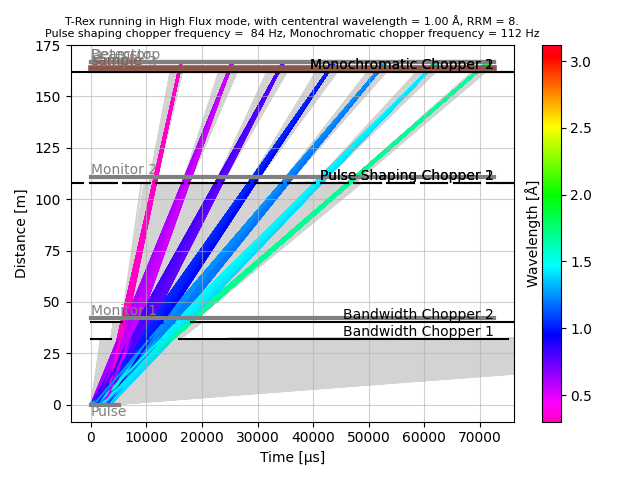

In [26]:
%matplotlib widget
import tof
import scipp as sc
from trex.instrument import Instrument

T_OFFSET = sc.scalar(1.7, unit="ms")
central_wavelength = sc.scalar(1, unit="Å")
rrm: int = 8  # repetition rate multiplication factor
mode = "High Flux"  # Chopper mode

source = tof.Source(facility="ess", neutrons=5_000_000, pulses=1)  # type: ignore
trex = Instrument(
    wavelength=central_wavelength, rrm=rrm, mode=mode, t_offset=T_OFFSET, source=source
)

sample = tof.InelasticSample(
    distance=sc.scalar(163.8, unit="m"),
    name="sample",
    delta_e=sc.DataArray(
        data=sc.array(dims=["en"], values=[1.0, 1.0], unit=""),
        coords={"en": sc.array(dims=["en"], values=[-5.0, 5.0], unit="meV")},
    ),
)  # type: ignore


res = trex.model(sample).run()
p = res.plot(visible_rays=5_000_000, blocked_rays=50_000)

p.ax.set_title(trex, fontsize=8)
p.ax.grid(alpha=0.6)
p.fig.tight_layout()